# Figure 3

In order to run this notebook, you need the following Anipose project:
- `202505-eeg-redose`

For a swifter run, you can download a local version of the already generated facial features:
- `redose-eeg-slow-drift.pkl`

Even though the EEG signal did not make it to the final figures, it is used to determine when the door was opened, allowing for more precise time "gap" calculation.
- `redose-eeg-time-gap.pkl`
- `open-door-time-gap.pkl`

In [1]:
%load_ext autoreload
%autoreload 2

# Update path as if notebook was run from top-level repo directory
import os
import sys

pwd = %pwd
if pwd.endswith('notebooks'):
    sys.path.insert(0, os.path.abspath('..'))
    new_pwd = os.path.abspath(f"{pwd}/..")
    %cd {new_pwd}

/data/disk2/irenenozal/mouse-fe-analysis


/home/irenenozal/micromamba/envs/mouse-fe-analysis/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import itertools
import pickle
import json
from glob import glob
from numpy import newaxis as na
from datetime import datetime
from pathlib import Path
from functools import reduce
import scipy.stats as stats
from scipy.stats import pearsonr, ttest_rel, wilcoxon, mannwhitneyu
from scipy.signal import convolve, spectrogram, sosfilt, iirdesign
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from matplotlib.colors import ListedColormap
from datetime import datetime

from fepipeline.features.landmarks import read_3d_data
from fepipeline.anatomy import compute_measurements_df
from labutils.utils import maybe
from labutils.plotting import (sns_setup,
                               landmark_cmap,
                               measurements_cmap,
                               save_figure)

In [3]:
np.random.seed(42)

In [4]:
# Colormaps
REDOSE_CMAP = {"A1": sns.color_palette("colorblind")[2],
                "A2": sns.color_palette("colorblind")[-1],
                "A3": sns.color_palette("colorblind")[-4],
                "B1": sns.color_palette("colorblind")[3],
                "B2": sns.color_palette("colorblind")[5],             
                "B3": sns.color_palette("colorblind")[0]}

REGION_ORDER = ["eye(left)", "eye(right)",
                "ear(left)", "ear(right)",
                "nose", "cheek", "mouth"]

_, LANDMARK_CMAP = landmark_cmap()
_, MEASUREMENT_CMAP = measurements_cmap()

CONTROL_CMAP = sns.color_palette([sns.color_palette("colorblind")[2],
                                  sns.color_palette("colorblind")[-3],
                                  sns.color_palette("colorblind")[3]])

FREQ_CMAP = "jet"


In [5]:
# Data cache
DATA_CACHE = "redose-measurements-data-cache" 
os.makedirs(DATA_CACHE, exist_ok=True)
MEAS_DATA_CACHE = os.sep.join([DATA_CACHE, "redose-eeg-slow-drift.pkl"])
ALL_DATA_CACHE = os.sep.join([DATA_CACHE, "redose-eeg-slow-drift-all.pkl"])

REDOSING_OFFSET_CACHE = os.sep.join([DATA_CACHE, "redose-eeg-time-gap.pkl"])
DOOR_INFO_CACHE = os.sep.join([DATA_CACHE, "open-door-time-gap.pkl"])

ANIPOSE_BASE = 'anipose-projects/202505-eeg-redose'

## Functions

In [6]:
def z_score(raw_data):
    mean = np.mean(raw_data, 0, keepdims=True)
    sigma = np.std(raw_data, 0, keepdims=True) #1
    sigma[sigma == 0] = 1
    return (raw_data-mean)/sigma

def un_zscore(raw_data, z_score_data): #Undo z-scoring for plotting as a sanity check - there is no deformation
    mean = np.mean(raw_data, 0, keepdims=True) #0
    sigma = np.std(raw_data, 0, keepdims=True) #1
    sigma[sigma == 0] = 1
    return z_score_data*sigma + mean

def moving_avg_filter(signal, window = 3, stride = 1, truncate = True):
    kernel = np.ones(window) / window
    result = convolve(signal, kernel, mode="same")[window:-window]

    return result[::stride]

def moving_variance(signal, window, stride):
    vars = np.ones(len(signal))
    for t in range(len(signal)):
        if t > window or t < (len(signal) - 1 - window):
            vars[t] = np.var(signal[t - window//2 : t + window//2])

    return vars[window:-window][::stride]

In [7]:
def compute_rms(signal, t_window):
    t_start, t_end = t_window
    # t_start = int(t_start*FPS + OFFSET)
    # t_end = int(t_end*FPS + OFFSET)
    rms = np.sqrt(np.sum(signal[t_start:t_end]**2)/len(signal[t_start:t_end]))

    return rms

In [8]:
def compute_sample_rate(timestamps):
    start_time = datetime.strptime(timestamps[0], "%H:%M:%S:%f")
    times = np.array([(datetime.strptime(t, "%H:%M:%S:%f") - start_time).total_seconds()
                      for t in timestamps])

    return 1 / np.mean(np.diff(times))

def read_signal(filename, sample_rate):
    df = pd.read_csv(filename, sep="\t", names=["timestamp", "signal"])
    _sample_rate = compute_sample_rate(df["timestamp"].values)
    if abs(sample_rate - _sample_rate) / sample_rate > 0.1:
        return df["signal"].values, _sample_rate
    else:
        return df["signal"].values, sample_rate

In [9]:
def compute_cum_runvar(mouse, date, df, meas, pad, window_size, FILTER_WINDOW, REDOSING_OFFSET, EEG_LAGS):
    meas_row = df.query("mouse == @mouse & "
                            "date == @date & "
                            "condition == 'anes' & "
                            "measurement_name == @meas")
    
    sample_rate = meas_row["sample_rate"].values[0]

    timeseries = meas_row["timeseries"].values[0]

    timeseries = z_score(moving_avg_filter(timeseries, FILTER_WINDOW))

    var_filter = 600 #in samples <> 1 min #previous window: 3000
    run_var = moving_variance(timeseries, window = var_filter, stride = 1) 
    cum_run_var = np.cumsum(run_var)
    
    offset = REDOSING_OFFSET[(date, mouse)] - EEG_LAGS[(date, mouse)] # when door closes after redosing, in seconds
    pad_in = pad #in minutes
    pad_out = pad + window_size #in minutes 
    # in time: [-pad_out, -pad_in] 0 [pad_in, pad_out] min - converted to sample idx below
    before_window = [int((offset - pad_out * 60) * sample_rate), int((offset - pad_in * 60) * sample_rate)] 
    after_window = [int((offset + pad_in * 60) * sample_rate), int((offset + pad_out * 60) * sample_rate)] 

    return run_var, cum_run_var, before_window, after_window

## Load data

Define experiment times (i.e., when the mouse was put on the rig after the first injection, when the second injection happened)

In [10]:
# Start of anesthesia video after injection (in seconds)
ANES_START_OFFSETS = {
    ("20250508", "B72"): 5 * 60 + 9, #anes video only
    ("20250508", "B74"): 8 * 60 + 26,
    ("20250509", "B75"): 6 * 60 + 2,
    ("20250509", "B73"): 7 * 60 + 10,
    ("20250522", "B72"): 4 * 60 + 10,
    ("20250522", "B73"): 4 * 20 + 10,
    ("20250522", "B74"): 5 * 60 + 1,
    ("20250522", "B75"): 4 * 60 + 9,
    ("20250523", "B72"): 4 * 60 + 0,
    ("20250523", "B73"): 3 * 60 + 44,
    ("20250523", "B74"): 3 * 60 + 27,
    ("20250523", "B75"): 4 * 60 + 4,
    ("20250527", "B72"): 3 * 60 + 29,
    ("20250527", "B73"): 3 * 60 + 0,
    ("20250527", "B74"): 3 * 60 + 4,
    ("20250527", "B75"): 4 * 60 + 10,
    ("20250528", "B72"): 6 * 60 + 20,
    ("20250528", "B74"): 3 * 60 + 40,
    ("20250528", "B75"): 5 * 60 + 57,
    ("20250617", "B72"): 4 * 60 + 5,
    ("20250617", "B74"): 3 * 60 + 48,
    ("20250617", "B75"): 4 * 60 + 38,
    ("20250618", "B72"): 3 * 60 + 38,
    ("20250618", "B74"): 3 * 60 + 31,
    ("20250618", "B75"): 5 * 60 + 10,
}

REDOSE = { # Time of the second injection
    ("20250508", "B72"): 34 * 60 + 0, 
    ("20250508", "B74"): 34 * 60 + 58,
    ("20250509", "B75"): 50 * 60 + 5,
    ("20250509", "B73"): 27 * 60 + 54,
    ("20250522", "B72"): 30 * 60 + 0,
    ("20250522", "B73"): 30 * 60 + 0,
    ("20250522", "B74"): 30 * 60 + 0,
    ("20250522", "B75"): 30 * 60 + 0,
    ("20250523", "B72"): 30 * 60 + 0,
    ("20250523", "B73"): 30 * 60 + 0,
    ("20250523", "B74"): 30 * 60 + 0,
    ("20250523", "B75"): 30 * 60 + 0,
    ("20250527", "B72"): 38 * 60 + 50,
    ("20250527", "B73"): 38 * 60 + 50,
    ("20250527", "B74"): 38 * 60 + 50,
    ("20250527", "B75"): 38 * 60 + 00,
    ("20250528", "B72"): 29 * 60 + 30,
    ("20250528", "B74"): 30 * 60 + 0,
    ("20250528", "B75"): 27 * 60 + 0,
    ("20250617", "B72"): 30 * 60 + 0,
    ("20250617", "B74"): 30 * 60 + 0,
    ("20250617", "B75"): 30 * 60 + 0,
    ("20250618", "B72"): 30 * 60 + 0,
    ("20250618", "B74"): 30 * 60 + 0,
    ("20250618", "B75"): 30 * 60 + 0,
}

REDOSE_SCHEME = { # Type of second injection ; A1 = saline, B1 = K+X
    ("20250522", "B72"): "A1",
    ("20250522", "B73"): "A1",
    ("20250522", "B74"): "B1",
    ("20250522", "B75"): "B1",
    ("20250523", "B72"): "B1",
    ("20250523", "B73"): "B1",
    ("20250523", "B74"): "A1",
    ("20250523", "B75"): "A1",
    ("20250527", "B72"): "B1", #"A2",
    ("20250527", "B73"): "B1", #"A2",
    ("20250527", "B74"): "A1", #"B2",
    ("20250527", "B75"): "A1", #"B2",
    ("20250528", "B72"): "A1", #"B2",
    ("20250528", "B74"): "B1", #"A2",
    ("20250528", "B75"): "B1", #"A2",
    ("20250617", "B72"): "B1", #"A3",
    ("20250617", "B74"): "A1", #"B3",
    ("20250617", "B75"): "A1", #"B3",
    ("20250618", "B72"): "A1", #"B3",
    ("20250618", "B74"): "B1", #"A3",
    ("20250618", "B75"): "B1", #"A3",
}


Load 3d data:

In [11]:
COORDINATE_PATHS = {}
key_cols = ('date', 'mouse', 'condition')
for p in Path(ANIPOSE_BASE).glob('*/pose-3d/*.csv'):
    date, mouse, *_ = p.name.split('_')
    condition = 'awake' if 'awake' in p.name else 'anes'
    COORDINATE_PATHS[(date, mouse, condition)] = p
data_keys = list(COORDINATE_PATHS.keys())
anes_data_keys = [d for d in data_keys if d[2] != 'awake']
data_keys

[('20250522', 'B74', 'awake'),
 ('20250528', 'B75', 'awake'),
 ('20250509', 'B75', 'anes'),
 ('20250617', 'B72', 'anes'),
 ('20250527', 'B75', 'awake'),
 ('20250522', 'B72', 'awake'),
 ('20250618', 'B74', 'anes'),
 ('20250523', 'B72', 'anes'),
 ('20250527', 'B72', 'anes'),
 ('20250527', 'B74', 'anes'),
 ('20250527', 'B72', 'awake'),
 ('20250618', 'B72', 'anes'),
 ('20250617', 'B72', 'awake'),
 ('20250508', 'B74', 'anes'),
 ('20250523', 'B74', 'awake'),
 ('20250618', 'B75', 'awake'),
 ('20250522', 'B73', 'awake'),
 ('20250522', 'B74', 'anes'),
 ('20250617', 'B74', 'anes'),
 ('20250617', 'B75', 'awake'),
 ('20250522', 'B75', 'anes'),
 ('20250522', 'B75', 'awake'),
 ('20250523', 'B72', 'awake'),
 ('20250528', 'B72', 'anes'),
 ('20250527', 'B74', 'awake'),
 ('20250523', 'B75', 'anes'),
 ('20250528', 'B72', 'awake'),
 ('20250522', 'B72', 'anes'),
 ('20250617', 'B75', 'anes'),
 ('20250522', 'B73', 'anes'),
 ('20250527', 'B73', 'anes'),
 ('20250618', 'B72', 'awake'),
 ('20250508', 'B72', 'ane

Compute (or load) facial measurements:

In [12]:
if os.path.exists(MEAS_DATA_CACHE):
    meas_df = pd.read_pickle(MEAS_DATA_CACHE)
else:
    coord_data = {k: read_3d_data(v.parent.parent.as_posix())
                  for k, v in COORDINATE_PATHS.items()}
    meas_df = compute_measurements_df(coord_data, key_columns=key_cols)
    meas_df = meas_df.assign(sample_rate=100.0, lag_time=0.0)
    pd.to_pickle(meas_df, MEAS_DATA_CACHE)
meas_df = meas_df.drop(columns=["measurement_value", "std", "count"])
meas_df

,date,mouse,condition,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,sample_rate,lag_time
382,20250523,B72,awake,ear,ear-width-left,mm,distance,"[7.714044738532176, 7.706300704429064, 7.71294...",100.0,0.0
558,20250508,B72,anes,mouth,mouth-area,mm^2,area,"[2.0661188629625347, 2.061779342183165, 2.0757...",100.0,0.0
559,20250508,B72,anes,nose,nose-bulge-volume,mm^3,volume,"[6.299800886863184, 6.297755483827305, 6.29746...",100.0,0.0
560,20250508,B72,anes,cheek,cheek-bulge-volume,mm^3,volume,"[31.10572720640851, 31.09835035151769, 31.0971...",100.0,0.0
220,20250617,B72,awake,cheek,cheek-bulge-volume,mm^3,volume,"[31.75499507877439, 31.916109906771343, 32.096...",100.0,0.0
...,...,...,...,...,...,...,...,...,...,...
266,20250618,B75,awake,ear,ear-angle-right,deg,angle,"[172.60121779842663, 172.8362586909529, 172.61...",100.0,0.0
265,20250618,B75,awake,ear,ear-angle-left,deg,angle,"[172.43646047784077, 172.256836078107, 171.853...",100.0,0.0
264,20250618,B75,awake,ear,ear-width-right,mm,distance,"[6.5389634135096655, 6.52939812095194, 6.53877...",100.0,0.0
328,20250617,B75,awake,eye,eye-area-right,mm^2,area,"[4.965019010916039, 4.921230265987274, 4.93044...",100.0,0.0


In [13]:
# make a session column for plotting ease
meas_df["session"] = list(zip(meas_df["date"], meas_df["mouse"], meas_df["condition"]))
meas_df.head()

,date,mouse,condition,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,sample_rate,lag_time,session
382,20250523,B72,awake,ear,ear-width-left,mm,distance,"[7.714044738532176, 7.706300704429064, 7.71294...",100.0,0.0,"(20250523, B72, awake)"
558,20250508,B72,anes,mouth,mouth-area,mm^2,area,"[2.0661188629625347, 2.061779342183165, 2.0757...",100.0,0.0,"(20250508, B72, anes)"
559,20250508,B72,anes,nose,nose-bulge-volume,mm^3,volume,"[6.299800886863184, 6.297755483827305, 6.29746...",100.0,0.0,"(20250508, B72, anes)"
560,20250508,B72,anes,cheek,cheek-bulge-volume,mm^3,volume,"[31.10572720640851, 31.09835035151769, 31.0971...",100.0,0.0,"(20250508, B72, anes)"
220,20250617,B72,awake,cheek,cheek-bulge-volume,mm^3,volume,"[31.75499507877439, 31.916109906771343, 32.096...",100.0,0.0,"(20250617, B72, awake)"


Compute (or load) door and redose info:

In [14]:
if os.path.exists(ALL_DATA_CACHE) and os.path.exists(REDOSING_OFFSET_CACHE):
    data = pd.read_pickle(ALL_DATA_CACHE)
    with open(REDOSING_OFFSET_CACHE, "rb") as fio:
        REDOSING_OFFSET = pickle.load(fio)
    with open(DOOR_INFO_CACHE, "rb") as fio:
        DOOR_INFO = pickle.load(fio)
else:
    eeg_rows = []
    REDOSING_OFFSET = {}
    DOOR_INFO = {}
    for date, mouse, cond in data_keys:
        folder = glob(f"ephys-data/{date}_*{mouse}*_redose-EEG_rig2")
        if len(folder) != 1:
            print(f"Found too many (or no) sources={folder} for {date=}, {mouse=}, {cond=}")
            continue
        with open(os.sep.join([folder[0], f"{date}_{mouse}_{cond}.align.json"])) as f:
            alignment = json.load(f)
            lag_time = alignment["lag_time"]
            sample_rate = alignment["sample_rate"]
        for name, units in (("eeg", "V"), ("emg", "V"), ("temp", "C")):
            filename = os.sep.join([folder[0], f"{date}_{mouse}_{cond}_{name}.txt"])
            signal, _sample_rate = read_signal(filename, sample_rate)
            not_nan = ~np.isnan(signal)
            start_idx = np.argmax(not_nan) # Returns the first non-nan
            end_idx = len(signal) - np.argmax(not_nan[::-1])
            if cond == 'awake':
                eeg_rows.append([date, mouse, cond,
                                "ephys", name, units, "ephys",
                                signal[start_idx:end_idx], _sample_rate, lag_time + start_idx / _sample_rate,
                                (date, mouse, cond)])
            else: #anes recording
                # get door open/close times
                door_open = np.argmax(~not_nan[start_idx:end_idx]) + start_idx
                # door_close = door_open + np.argmax(not_nan[door_open:end_idx])
                door_close = door_open + (len(not_nan[door_open:end_idx]) - np.argmax(~not_nan[door_open:end_idx][::-1])) # account for interrumpted on/off signal during door open
                signal_init = signal[start_idx:door_open]
                signal_redose = signal[door_close:end_idx]
                if name == 'eeg':
                    # print(date, mouse, cond)
                    # print(start_idx, door_open, door_close, end_idx)
                    REDOSING_OFFSET[date, mouse] = door_close / _sample_rate #door_open / _sample_rate ?
                    DOOR_INFO[date, mouse] = [(door_open, door_close), _sample_rate]
                eeg_rows.append([date, mouse, cond,
                                "ephys", name + '-init', units, "ephys",
                                signal_init, _sample_rate, lag_time + start_idx / _sample_rate,
                                (date, mouse, cond)])
                eeg_rows.append([date, mouse, cond,
                                "ephys", name + '-redose', units, "ephys",
                                signal_redose, _sample_rate, lag_time + start_idx / _sample_rate,
                                (date, mouse, cond)])

    data = pd.concat([meas_df, pd.DataFrame(eeg_rows, columns=meas_df.columns)])
    pd.to_pickle(data, ALL_DATA_CACHE)
    with open(REDOSING_OFFSET_CACHE, "wb") as fio:
        pickle.dump(REDOSING_OFFSET, fio)
    with open(DOOR_INFO_CACHE, "wb") as fio:
        pickle.dump(DOOR_INFO, fio)

data.head(5)

,date,mouse,condition,measurement_group,measurement_name,measurement_units,measurement_type,timeseries,sample_rate,lag_time,session
382,20250523,B72,awake,ear,ear-width-left,mm,distance,"[7.714044738532176, 7.706300704429064, 7.71294...",100.0,0.0,"(20250523, B72, awake)"
558,20250508,B72,anes,mouth,mouth-area,mm^2,area,"[2.0661188629625347, 2.061779342183165, 2.0757...",100.0,0.0,"(20250508, B72, anes)"
559,20250508,B72,anes,nose,nose-bulge-volume,mm^3,volume,"[6.299800886863184, 6.297755483827305, 6.29746...",100.0,0.0,"(20250508, B72, anes)"
560,20250508,B72,anes,cheek,cheek-bulge-volume,mm^3,volume,"[31.10572720640851, 31.09835035151769, 31.0971...",100.0,0.0,"(20250508, B72, anes)"
220,20250617,B72,awake,cheek,cheek-bulge-volume,mm^3,volume,"[31.75499507877439, 31.916109906771343, 32.096...",100.0,0.0,"(20250617, B72, awake)"


In [15]:
EEG_LAGS = {(row["date"], row["mouse"]): row["lag_time"] 
            for _, row in data.query("condition == 'anes' & measurement_type == 'ephys'").iterrows()}

In [16]:
# Define sessions that are going into the figures

select_sessions = {'B72': ['20250522', '20250523', '20250527', '20250528', '20250617', '20250618'],
                   'B73': ['20250522', '20250523'],
                   'B74': ['20250522', '20250523', '20250527', '20250528', '20250617', '20250618'],
                   'B75': ['20250522', '20250523', '20250527', '20250528']
                   }

## Panel j-k

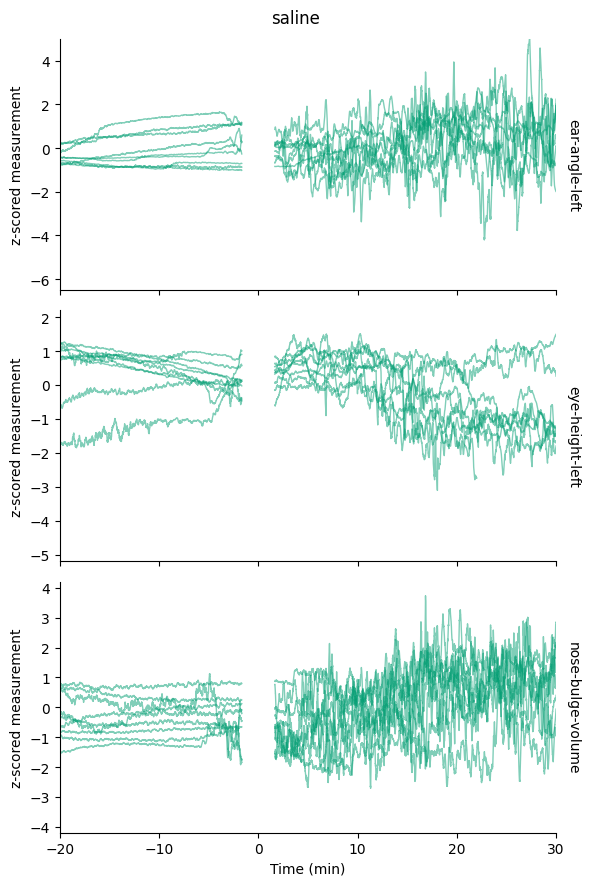

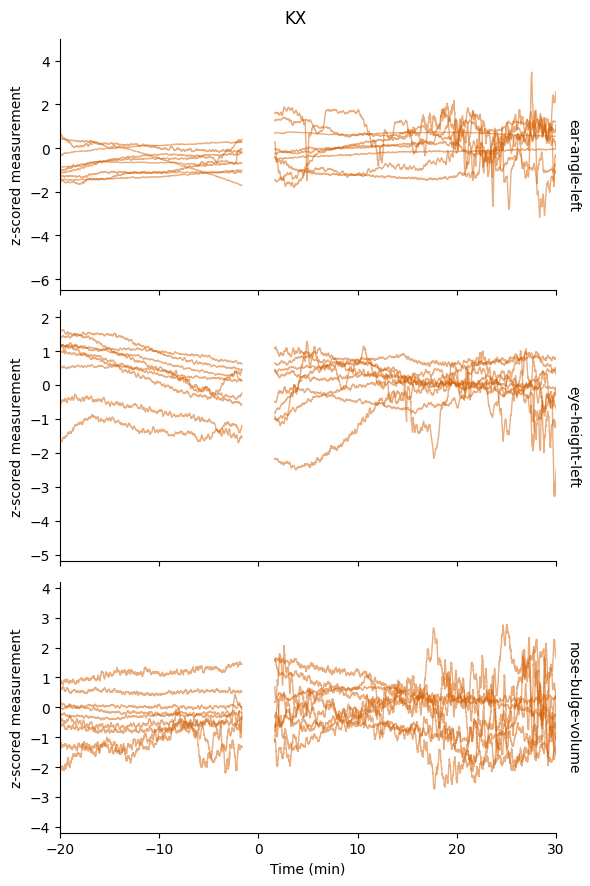

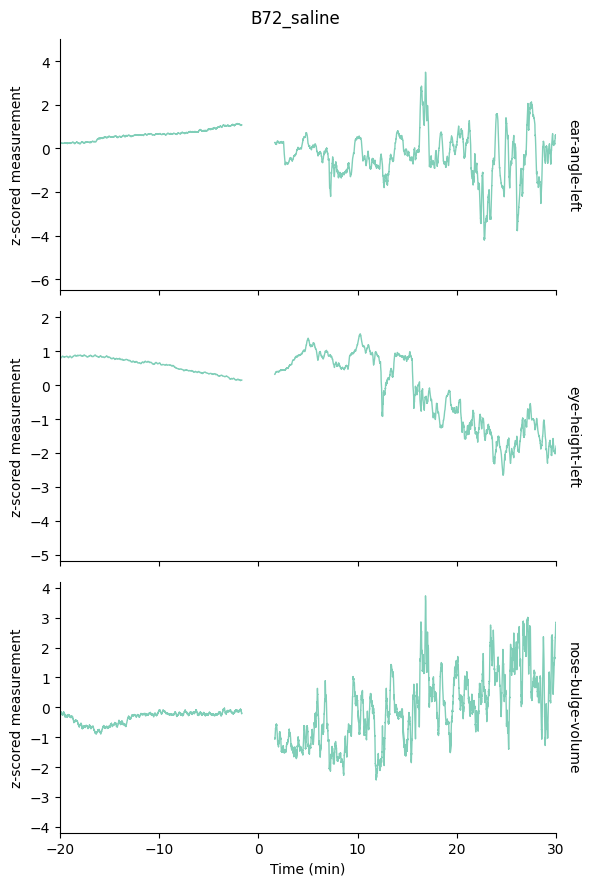

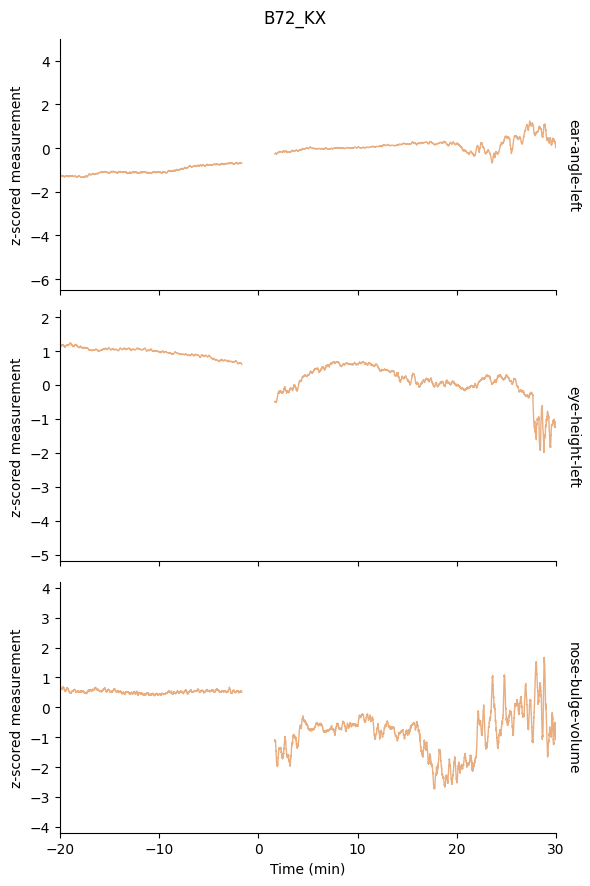

In [17]:
import matplotlib.patches as patches

measurements = ["ear-angle-left", "eye-height-left", "nose-bulge-volume"]
FILTER_WINDOW = 1000

def plot_measurements(timeseries, date, mouse, sample_rate, lag, color):
    for date, mouse, sample_rate, lag, ys in zip(date.values,
                                                 mouse.values,
                                                 sample_rate.values,
                                                 lag.values,
                                                 timeseries.values):
        # get anes start time
        anes_start = ANES_START_OFFSETS.get((date, mouse), 0)
        # get time points
        time = (np.arange(len(ys)) / sample_rate + lag + anes_start) / 60
        # get anes start time
        anes_start = ANES_START_OFFSETS.get((date, mouse), 0)
        # get time points
        time = (np.arange(len(ys)) / sample_rate + lag + anes_start) / 60
        time = time - REDOSE[(date, mouse)] / 60 # align to redose time
        time = time[FILTER_WINDOW:-FILTER_WINDOW]
        # average and z-score
        ys = z_score(moving_avg_filter(ys, FILTER_WINDOW))
        # Split trace before and after redosing (based on max mouse/date)
        # leave out time window when mouse was being injected the 2nd time (open door may make signal unreliable)
        _door_open = int(np.where(time == 0)[0][0] - 10000)
        _door_close = int(np.where(time == 0)[0][0] + 10000)
        ys_pre = ys[:_door_open]
        time_pre = time[:_door_open]
        ys_post = ys[_door_close:]
        time_post = time[_door_close:]
        # plot with redose time marked
        # sns.lineplot(x=time, y=ys, color=REDOSE_CMAP[REDOSE_SCHEME[date, mouse]], alpha = 0.5, linewidth = 1)
        sns.lineplot(x=time_pre, y=ys_pre, color=REDOSE_CMAP[REDOSE_SCHEME[date, mouse]], alpha = 0.5, linewidth = 1)
        sns.lineplot(x=time_post, y=ys_post, color=REDOSE_CMAP[REDOSE_SCHEME[date, mouse]], alpha = 0.5, linewidth = 1)

        
      
redose_query = {"saline": "((date == '20250522' & mouse in ['B72', 'B73']) | " \
                    "(date == '20250523' & mouse in ['B74', 'B75']) |"
                    "(date == '20250528' & mouse in ['B72']) | " \
                    "(date == '20250527' & mouse in ['B74', 'B75']) |" \
                    "(date == '20250618' & mouse in ['B72']) | " \
                    "(date == '20250617' & mouse in ['B74'])) &",
                "KX": "((date == '20250523' & mouse in ['B72', 'B73']) | " \
                    "(date == '20250522' & mouse in ['B74', 'B75']) |"
                    "(date == '20250527' & mouse in ['B72']) | " \
                    "(date == '20250528' & mouse in ['B74', 'B75']) |" \
                    "(date == '20250617' & mouse in ['B72']) | " \
                    "(date == '20250618' & mouse in ['B74'])) &",
                "B72_saline": "(date == '20250522' & mouse in ['B72']) &",
                "B72_KX": "(date == '20250523' & mouse in ['B72']) &"}

for injection in redose_query.keys():
    g = sns.FacetGrid(meas_df.query(redose_query[injection] + 
                                    "condition == 'anes' & " \
                                    "measurement_name in @measurements"),
                    row="measurement_name",
                    row_order = measurements,
                    sharex="col",
                    sharey=False,
                    aspect=2,
                    height=3,
                    margin_titles=True)
    g.map(plot_measurements, "timeseries", "date", "mouse", "sample_rate", "lag_time")
    g.set_titles(row_template="{row_name}")
    g.figure.suptitle(injection)
    g.set_ylabels("z-scored measurement")
    g.set_xlabels("Time (min)")
    g.set(xlim=[-20, 30])
    g.axes[0,0].set_ylim(-6.5, 5)
    g.axes[1,0].set_ylim(-5.2, 2.2)
    g.axes[2,0].set_ylim(-4.2, 4.2)
    g.tight_layout()

    plt.show()

    # save_figure('rev_figs/eeg/', f"{injection}", g, formats = ['pdf', 'svg'])

## Panel l

In [18]:
# compute the mean (or to be changed to other metric, e.g., rms) 
# of the cum running var for a time window before and after 0 (redose time
    
time_pads = [5, 10, 15] #in minutes ; time away from 0
window_size = 5 #in minutes ; used to compute the metric
cum_run_var_mean = []

for pad in time_pads:
    for mouse, dates in select_sessions.items():
        for date in dates:
            for meas in measurements:
                run_var, cum_run_var, before_window, after_window = compute_cum_runvar(mouse, date, 
                                                                                       meas_df, meas, 
                                                                                       pad, window_size,
                                                                                       FILTER_WINDOW, 
                                                                                       REDOSING_OFFSET, 
                                                                                       EEG_LAGS) 
                cum_run_var_mean.append([mouse, date, meas, "before", (-(pad + window_size), -pad), pad,
                                         np.mean(run_var[before_window]),
                                        np.mean(cum_run_var[before_window])])
                cum_run_var_mean.append([mouse, date, meas, "after", (pad, pad + window_size), pad,
                                         np.mean(run_var[after_window]),
                                        np.mean(cum_run_var[after_window])])

cum_run_var_mean_df = pd.DataFrame(cum_run_var_mean, columns = ["mouse", 
                                                                "date", 
                                                                "measurement", 
                                                                "regime", 
                                                                "time_window", 
                                                                "time_pad",
                                                                "mean_run_var",
                                                                "mean_cum_run_var"])


/home/irenenozal/micromamba/envs/mouse-fe-analysis/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/irenenozal/micromamba/envs/mouse-fe-analysis/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/irenenozal/micromamba/envs/mouse-fe-analysis/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/irenenozal/micromamba/envs/mouse-fe-analysis/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/irenenozal/micromamba/envs/mouse-fe-analysis/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWar

In [19]:
def add_redose_scheme(row):
    date = row["date"]
    mouse = row["mouse"]
    
    return REDOSE_SCHEME[date,mouse]

cum_run_var_mean_df["redose"] = cum_run_var_mean_df.apply(add_redose_scheme, axis=1)

# Compute the difference in cumulative running variance before and after 2nd injection
var_diff_list = []
for mouse in set(cum_run_var_mean_df["mouse"]):
    for redose in set(REDOSE_SCHEME.values()):
        before_df = cum_run_var_mean_df.query("mouse == @mouse & redose == @redose & regime == 'before'")
        after_df = cum_run_var_mean_df.query("mouse == @mouse & redose == @redose & regime == 'after'")
        for date in set(before_df["date"]):
            for meas in set(before_df["measurement"]):
                for time_pad in set(before_df["time_pad"]):
                    before_var = before_df.query("date == @date & measurement == @meas & time_pad == @time_pad")["mean_run_var"].values
                    after_var = after_df.query("date == @date & measurement == @meas & time_pad == @time_pad")["mean_run_var"].values
                    before_cum_var = before_df.query("date == @date & measurement == @meas & time_pad == @time_pad")["mean_cum_run_var"].values
                    after_cum_var = after_df.query("date == @date & measurement == @meas & time_pad == @time_pad")["mean_cum_run_var"].values

                    var_diff_list.append([date, mouse, redose, meas, time_pad, 
                                        np.abs(after_var - before_var)[0],
                                        np.abs(after_cum_var - before_cum_var)[0]])
                
var_diff_df = pd.DataFrame(var_diff_list, columns=["date", "mouse", "redose", 
                                                   "measurement", "time_pad", 
                                                   "var_diff", "cum_var_diff"])
var_diff_df.head(3)


,date,mouse,redose,measurement,time_pad,var_diff,cum_var_diff
0,20250528,B75,B1,eye-height-left,10,0.000088,96.525321
1,20250528,B75,B1,eye-height-left,5,0.000134,83.328829
2,20250528,B75,B1,eye-height-left,15,0.000243,109.786983


/tmp/ipykernel_1122954/3028550018.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[col].set_xticklabels(['Saline', 'K+X'])
/tmp/ipykernel_1122954/3028550018.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[col].set_xticklabels(['Saline', 'K+X'])
/tmp/ipykernel_1122954/3028550018.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[col].set_xticklabels(['Saline', 'K+X'])


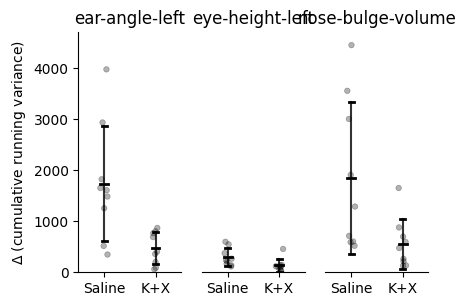

In [20]:
import seaborn.objects as so

fig, ax = plt.subplots(1,3, figsize = (7,4))
var_diff_df_sorted = var_diff_df.sort_values(by='redose')

for col, meas in enumerate(['ear-angle-left', 'eye-height-left', 'nose-bulge-volume']):
    p = (so.Plot(var_diff_df_sorted.query("time_pad == 15 & measurement == @meas"), 
                                    x="redose", y="cum_var_diff")
                # plot scatter of samples
                .add(so.Dot(alpha=0.3, pointsize=4, color = 'black'), so.Jitter()) #, dodge_shift, so.Jitter())
                # plot mean bar
                .add(so.Dash(linewidth=2, width=0.15, color = 'black'), so.Agg()) #, dodge_shift_agg)
                # plot stddev whiskers
                .add(so.Dash(linewidth=2, width=0.1, color = 'black'),
                    so.Agg(lambda x: x.mean() + x.std(ddof=1)))
                    # dodge_shift_agg)
                .add(so.Dash(linewidth=2, width=0.1, color = 'black'),
                    so.Agg(lambda x: x.mean() - x.std(ddof=1)))
                    # dodge_shift_agg)
                # connect mean to whiskers (stddev range)
                .add(so.Range(alpha=0.8, color = 'black'), so.Est(errorbar="sd")) #, dodge_shift_agg)
                # .theme({"axes.prop_cycle": cmap})
                .layout(extent=(0.2, 0.2, 0.7, 0.8))
                .label(x = None, y = None)
                .on(ax[col]).plot())
    ax[col].set_ylim(0, 4700)
    ax[col].set_title(meas)
    ax[col].set_xticklabels(['Saline', 'K+X'])
    sns.despine(ax = ax[col])
    if col != 0:
        sns.despine(ax = ax[col], left=True)
        # ax[col].set_ylabel(None)
        # ax[col].set_yticklabels([])
        ax[col].tick_params(axis='y', which='both', left=False, right=False, labelleft=False) # Remove y-axis ticks and labels
    else:
        ax[col].set_yticks(np.arange(0,4001, 1000))
        ax[col].set_ylabel("$\Delta$ (cumulative running variance)")

# save_figure('rev_figs/eeg/', "cum_var_diff_sal_vs_kx_per_meas_nobox", fig, formats = ['svg'])

### Stats

In [21]:
from itertools import (combinations, product)
def generate_groups(datapoints): #datapoints is a list with dates - separate dates into two groups
    groups = []
    indeces = np.arange(0, len(datapoints))
    for gr in combinations(indeces, int(len(indeces)/2)):
        gr1 = list(gr)
        gr2 = list(num for num in indeces if num not in gr1)
        # if gr1 < gr2: #groups ((0, 1), (2, 3)) are the same as ((2, 3), (0, 1))
        groups.append([[dp for idx, dp in enumerate(datapoints) if idx in gr1], 
                        [dp for idx, dp in enumerate(datapoints) if idx in gr2]])
    
    return groups

test = generate_groups(np.arange(0,6))
# test = generate_groups(['20250522', '20250523', '20250527', '20250528', '20250617', '20250618'])
test

[[[0, 1, 2], [3, 4, 5]],
 [[0, 1, 3], [2, 4, 5]],
 [[0, 1, 4], [2, 3, 5]],
 [[0, 1, 5], [2, 3, 4]],
 [[0, 2, 3], [1, 4, 5]],
 [[0, 2, 4], [1, 3, 5]],
 [[0, 2, 5], [1, 3, 4]],
 [[0, 3, 4], [1, 2, 5]],
 [[0, 3, 5], [1, 2, 4]],
 [[0, 4, 5], [1, 2, 3]],
 [[1, 2, 3], [0, 4, 5]],
 [[1, 2, 4], [0, 3, 5]],
 [[1, 2, 5], [0, 3, 4]],
 [[1, 3, 4], [0, 2, 5]],
 [[1, 3, 5], [0, 2, 4]],
 [[1, 4, 5], [0, 2, 3]],
 [[2, 3, 4], [0, 1, 5]],
 [[2, 3, 5], [0, 1, 4]],
 [[2, 4, 5], [0, 1, 3]],
 [[3, 4, 5], [0, 1, 2]]]

In [22]:
select_meas = set(var_diff_df["measurement"])
n_samples = len(set(var_diff_df["mouse"]))
stats_meas = {}
stats_truth = {}
# loop over the different selected measurements
for meas in select_meas:
    stats_meas[meas] = []
    perm_test = []
    all_means = []
    all_truth = []
    # loop over all the mice
    for mouse_count, mouse in enumerate(set(var_diff_df["mouse"])):
        mouse_means = []
        sub_df = var_diff_df.query("mouse == @mouse & "
                                   "measurement == @meas & "
                                   "time_pad == 15")
        mouse_dates = list(set(sub_df["date"].values))
        true_sal_dates = [k[0] for k, val in REDOSE_SCHEME.items() if k[1] == mouse and val == 'A1']
        true_KX_dates = [d for d in mouse_dates if d not in true_sal_dates]
        # print(mouse, true_sal_dates, true_KX_dates)
        if mouse == 'B75': #Remove the last saline session, which does not have a subsequent KX day
            true_sal_dates = true_sal_dates[:-1] 
        # generate all possible combinations of dates for one mouse
        date_groups = generate_groups(mouse_dates)
        # print(mouse, date_groups)
        for dg in date_groups:
            # print(mouse, dg, true_sal_dates, true_KX_dates)
            group1 = sub_df.query("date in @dg[0]")["cum_var_diff"].values
            group2 = sub_df.query("date in @dg[1]")["cum_var_diff"].values
            # group1 = np.mean(sub_df.query("date in @dg[0]")["cum_var_diff"].values)
            # group2 = np.mean(sub_df.query("date in @dg[1]")["cum_var_diff"].values)
            # print(dg, mouse, group1, group2)
            if sorted(dg[0]) == sorted(true_sal_dates): # and len(all_truth) < (mouse_count + 1): #Make sure the true groupings are always in the same order
                all_truth.append([group1, group2])
                # perm_test.append([sub_df.query("date in @dg[0]")["cum_var_diff"].values,
                #                  sub_df.query("date in @dg[1]")["cum_var_diff"].values])
                mouse_means.append([group1, group2])
            # elif sorted(dg[0]) == sorted(true_KX_dates) and len(all_truth) < (mouse_count + 1):
            #     all_truth.append([group2, group1])
            #     # perm_test.append([sub_df.query("date in @dg[1]")["cum_var_diff"].values,
            #     #                  sub_df.query("date in @dg[0]")["cum_var_diff"].values])
            #     mouse_means.append([group2, group1])
            else:
                mouse_means.append([group1, group2])
            # print(mouse, meas, perm_test)
        # print(mouse, meas, all_truth)
        all_means.append(mouse_means)
    # print(meas, all_truth)
    combo_array = np.stack([
            np.concatenate([c[0] for c in all_truth], axis=0),
            np.concatenate([c[1] for c in all_truth], axis=0),
        ], axis=-1)
    #below: n_mice, n_possible_date_combos, n_date_pairs (always 2), n_total_dates_per_mouse/2 
    # print(len(all_means), len(all_means[0]), len(all_means[0][0]), len(all_means[0][0][0])) 
    # print(*all_means)
    u1, pval_true =  mannwhitneyu(combo_array[:,0], combo_array[:,1], alternative='two-sided')
    u_true = np.min([u1, n_samples**2 - u1]) #Find the minimum u (u1 or u2)
    stats_truth[meas] =  [u_true, pval_true]
    # loop over all possible combinations of 4 values (i.e., 1 value per mouse)
    for combo in list(product(*all_means)):
        # combo_array = np.stack(combo)
        # print("all_truth:", all_truth, "\ncombo:", combo)
        combo_array = np.stack([
            np.concatenate([c[0] for c in combo], axis=0),
            np.concatenate([c[1] for c in combo], axis=0),
        ], axis=-1)
        u1, pval = mannwhitneyu(combo_array[:,0], combo_array[:,1], alternative='two-sided') #no assumption about the underlying distribution
        stats_meas[meas].append(np.min([u1, n_samples**2 - u1]))
    null_u = n_samples**2/2
    # print(u_true)
    # print(stats_meas[meas])
    # stat_result = np.sum(np.abs(u_true - null_u) <= np.abs(np.array(stats_meas[meas]) - null_u)) / len(stats_meas[meas])
    stat_result = np.sum(int(u_true) >= np.array(stats_meas[meas]).astype(int)) / len(stats_meas[meas])
    # print(len(stats_meas[meas]))
    print(f"{meas}: p-value = {stat_result}") #, {u_true}, {stats_meas[meas]}")
        


eye-height-left: p-value = 0.0060416666666666665
nose-bulge-volume: p-value = 0.005625
ear-angle-left: p-value = 0.005416666666666667
